In [43]:
# ==========================================
# MPI-E1 | S1 | T1
# Load dataset into Jupyter Notebook
# ==========================================

import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/ASUS/Downloads/HCL_Final/data/raw/MPIA_RAW_DATA.csv")

df.head()

,employee_id,manager_id,manager_name,department,manager_experience,leadership_score,communication_score,manager_performance_score,employee_performance,satisfaction_score,attrition,project_success_score,revenue_generated
0,EMP_0001,1.0,Amit Sharma,Sales,NaN,7.07,7.88,7.47,5.80,25.40,Yes,6.21,75520.09 INR
1,EMP_0002,3.0,Neha Jain,Sales,NaN,8.21,7.70,7.96,8.03,10.00,No,7.46,88426.79
2,EMP_0003,3.0,Neha Jain,Sales,9.0,8.21,7.70,7.96,NaN,9.32,No,6.52,86885.47
3,EMP_0004,6.0,Sneha Kapoor,Sales,8.0,7.98,8.08,8.03,7.62,8.21,No,8.49,83466.89
4,EMP_0005,9.0,Vikas Yadav,IT,15.0,8.31,8.03,8.17,8.65,NaN,No,nan USD,83088.54


In [44]:
# ==========================================
# MPI-E1 | S1 | T2
# Inspect dataset structure
# ==========================================

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (331, 13)

Columns:
 Index(['employee_id', 'manager_id', 'manager_name', 'department',
       'manager_experience', 'leadership_score', 'communication_score',
       'manager_performance_score', 'employee_performance',
       'satisfaction_score', 'attrition', 'project_success_score',
       'revenue_generated'],
      dtype='str')

Data Types:
 employee_id                      str
manager_id                   float64
manager_name                     str
department                       str
manager_experience           float64
leadership_score             float64
communication_score          float64
manager_performance_score    float64
employee_performance         float64
satisfaction_score           float64
attrition                        str
project_success_score            str
revenue_generated                str
dtype: object


In [45]:
# ==========================================
# MPI-E1 | S1 | T3
# Generate summary statistics
# ==========================================

df.describe(include='all')

,employee_id,manager_id,manager_name,department,manager_experience,leadership_score,communication_score,manager_performance_score,employee_performance,satisfaction_score,attrition,project_success_score,revenue_generated
count,296,305.000000,312,306,306.000000,304.000000,304.000000,306.000000,288.000000,276.000000,312,312,294
unique,282,NaN,30,9,NaN,NaN,NaN,NaN,NaN,NaN,13,206,277
top,nan,NaN,Rohit Singh,Sales,NaN,NaN,NaN,NaN,NaN,NaN,No,10.0,nan
freq,6,NaN,24,97,NaN,NaN,NaN,NaN,NaN,NaN,144,9,5
mean,NaN,7.222951,NaN,NaN,13.686275,8.433059,8.607961,9.334510,8.501528,9.496341,NaN,NaN,NaN
std,NaN,5.157021,NaN,NaN,9.287376,3.499626,3.356873,6.818703,5.093493,6.861938,NaN,NaN,NaN
min,NaN,1.000000,NaN,NaN,8.000000,6.940000,6.650000,7.120000,5.000000,5.370000,NaN,NaN,NaN
25%,NaN,4.000000,NaN,NaN,10.000000,7.230000,7.700000,7.470000,6.557500,7.465000,NaN,NaN,NaN
50%,NaN,7.000000,NaN,NaN,11.000000,7.580000,8.030000,7.790000,7.325000,8.010000,NaN,NaN,NaN
75%,NaN,9.000000,NaN,NaN,15.000000,7.980000,8.080000,8.030000,8.082500,8.762500,NaN,NaN,NaN


In [46]:
# ==========================================
# MPI-E1 | S2 | T4
# Analyze missing values
# ==========================================

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

print(pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
}))

                           Missing Count  Missing %
employee_id                           35  10.574018
manager_id                            26   7.854985
manager_name                          19   5.740181
department                            25   7.552870
manager_experience                    25   7.552870
leadership_score                      27   8.157100
communication_score                   27   8.157100
manager_performance_score             25   7.552870
employee_performance                  43  12.990937
satisfaction_score                    55  16.616314
attrition                             19   5.740181
project_success_score                 19   5.740181
revenue_generated                     37  11.178248


In [47]:
# ==========================================
# MPI-E1 | S2 | T5
# Identify duplicate records
# ==========================================

duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 1


In [48]:
# ==========================================
# MPI-E1 | S2 | T6
# Check categorical consistency
# ==========================================

for col in df.select_dtypes(include=['object', 'string']).columns:
    print(f"\n🔹 Column: {col}")
    print(df[col].unique())


🔹 Column: employee_id
<ArrowStringArray>
[  'EMP_0001',   'EMP_0002', ' EMP_0003 ',   'EMP_0004', ' EMP_0005 ',
          nan,   'EMP_0007',   'EMP_0008',   'EMP_0009',   'EMP_0011',
 ...
   'EMP_0297', ' EMP_0298 ',   'EMP_0299',   'EMP_0300',   'EMP_0267',
   'EMP_0010', ' EMP_0234 ',   'EMP_0006', ' EMP_0176 ',   'EMP_0219']
Length: 283, dtype: str

🔹 Column: manager_name
<ArrowStringArray>
[     ' Amit Sharma ',          'Neha Jain',       'Sneha Kapoor',
      ' Vikas Yadav ',     ' Sneha Kapoor ',   ' Pooja Malhotra ',
      ' Priya Verma ',      '  Neha Jain  ',        'Amit Sharma',
      ' Rohit Singh ',      ' Karan Mehta ',       ' Meera Shah ',
        'Rohit Singh',        'Karan Mehta',              ' nan ',
     'Pooja Malhotra',       'Anjali Patel',       ' Arjun Nair ',
                  nan,     ' Anjali Patel ',        'Rahul Gupta',
      ' Rahul Gupta ',         'Arjun Nair',        'Vikas Yadav',
     '  Meera Shah  ',        'Priya Verma',         'Meera Shah',

In [49]:
# ==========================================
# MPI-E2 | S1 | T7
# Handle missing values
# ==========================================

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns

# 🔥 REMOVE ID column from categorical
cat_cols = [col for col in cat_cols if col != 'employee_id']

# Numeric → median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → mode (excluding employee_id)
for col in cat_cols:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

# 🔥 HANDLE employee_id separately
df = df.dropna(subset=['employee_id'])

In [50]:
# ==========================================
# MPI-E2 | S1 | T8
# Convert data types
# ==========================================

df['revenue_generated'] = pd.to_numeric(df['revenue_generated'], errors='coerce')
df['project_success_score'] = pd.to_numeric(df['project_success_score'], errors='coerce')

# 🔥 FIX: handle new nulls created
df['revenue_generated'] = df['revenue_generated'].fillna(df['revenue_generated'].median())
df['project_success_score'] = df['project_success_score'].fillna(df['project_success_score'].median())

In [51]:
# ==========================================
# MPI-E2 | S1 | T9
# Standardize categorical values
# ==========================================

cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [52]:
# ==========================================
# MPI-E2 | S2 | T10
# Detect outliers using IQR
# ==========================================

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))]
    
    print(f"{col}: {len(outliers)} outliers")

manager_id: 9 outliers
manager_experience: 12 outliers
leadership_score: 15 outliers
communication_score: 31 outliers
manager_performance_score: 13 outliers
employee_performance: 21 outliers
satisfaction_score: 15 outliers
project_success_score: 14 outliers
revenue_generated: 10 outliers


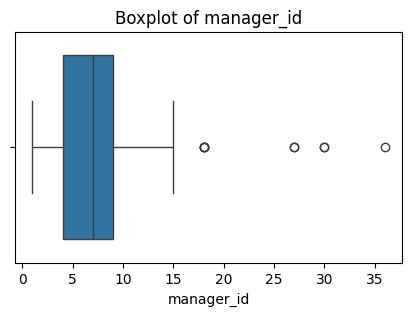

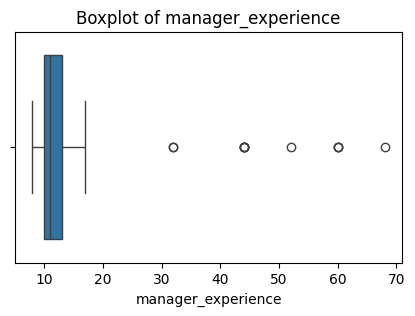

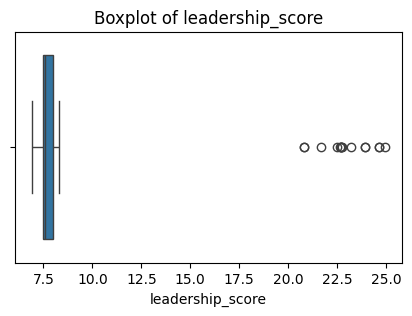

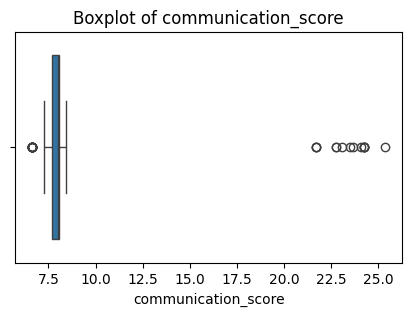

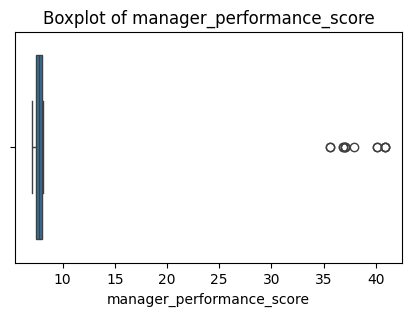

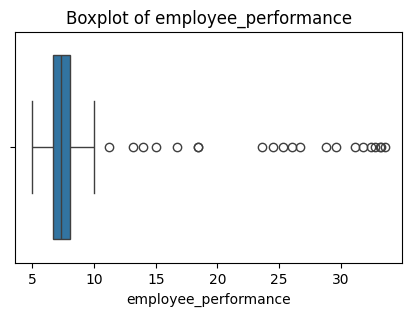

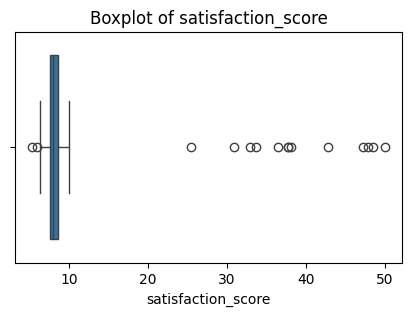

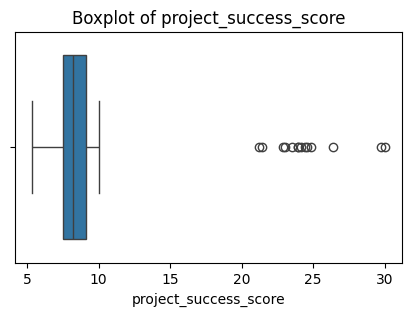

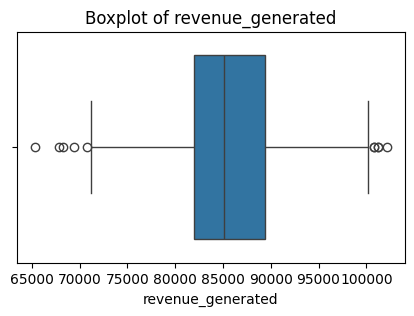

In [53]:
# ==========================================
# MPI-E2 | S2 | T11
# Visualize outliers using boxplots
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [54]:
# ==========================================
# MPI-E2 | S2 | T12
# Treat outliers
# ==========================================

for col in num_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    df[col] = df[col].clip(lower, upper)

# 🔥 Safety check after capping
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [55]:
# ==========================================
# MPI-E3 | S1 | T13
# Encoding NOT required for dashboard
# ==========================================

print("Skipping encoding - not required for EDA/dashboard")

Skipping encoding - not required for EDA/dashboard


In [56]:
# ==========================================
# MPI-E3 | S1 | T14
# Create derived features
# ==========================================

df['performance_efficiency'] = df['employee_performance'] / (df['manager_performance_score'] + 1)

In [57]:
# ==========================================
# MPI-E3 | S1 | T15
# Validate dataset
# ==========================================

print("Total Null Values:", df.isnull().sum().sum())
print(df.isnull().sum())

Total Null Values: 0
employee_id                  0
manager_id                   0
manager_name                 0
department                   0
manager_experience           0
leadership_score             0
communication_score          0
manager_performance_score    0
employee_performance         0
satisfaction_score           0
attrition                    0
project_success_score        0
revenue_generated            0
performance_efficiency       0
dtype: int64


In [58]:
# ==========================================
# MPI-E3 | S2 | T16
# Final validation
# ==========================================

df.describe()

,manager_id,manager_experience,leadership_score,communication_score,manager_performance_score,employee_performance,satisfaction_score,project_success_score,revenue_generated,performance_efficiency
count,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000,296.000000
mean,7.113007,13.050676,8.397613,8.589628,9.079645,8.458280,9.377414,8.912140,85358.883046,0.925553
std,4.382278,7.871907,3.371094,3.313912,6.241888,4.974287,6.531046,3.469842,6374.182462,0.542040
min,1.000000,8.000000,6.940000,6.650000,7.120000,5.000000,6.289000,5.828000,69339.128000,0.121403
25%,4.000000,10.000000,7.500000,7.700000,7.470000,6.690000,7.590000,7.500000,81950.382500,0.752560
50%,7.000000,11.000000,7.580000,8.030000,7.790000,7.325000,8.010000,8.195000,85100.030000,0.833333
75%,9.000000,13.000000,7.980000,8.080000,8.030000,8.015000,8.610000,9.080000,89357.355000,0.908025
max,27.150000,60.000000,23.974500,24.240000,40.185000,32.782000,47.232500,24.916500,100861.272500,3.870366


In [59]:
# ==========================================
# MPI-E3 | S2 | T17
# Preview final dataset
# ==========================================

df.head()

,employee_id,manager_id,manager_name,department,manager_experience,leadership_score,communication_score,manager_performance_score,employee_performance,satisfaction_score,attrition,project_success_score,revenue_generated,performance_efficiency
0,emp_0001,1.0,amit sharma,sales,11.0,7.07,7.88,7.47,5.800,25.40,yes,6.210,85100.03,0.684770
1,emp_0002,3.0,neha jain,sales,11.0,8.21,7.70,7.96,8.030,10.00,no,7.460,88426.79,0.896205
2,emp_0003,3.0,neha jain,sales,9.0,8.21,7.70,7.96,7.325,9.32,no,6.520,86885.47,0.817522
3,emp_0004,6.0,sneha kapoor,sales,8.0,7.98,8.08,8.03,7.620,8.21,no,8.490,83466.89,0.843854
4,emp_0005,9.0,vikas yadav,it,15.0,8.31,8.03,8.17,8.650,8.01,no,8.195,83088.54,0.943293


In [60]:
# ==========================================
# MPI-E3 | S2 | T18
# Export cleaned dataset
# ==========================================

df.to_csv("C:/Users/ASUS/Downloads/HCL_Final/data/processed/MPIA_EDA_READY2.csv", index=False)

print("✅ Dataset saved successfully!")

✅ Dataset saved successfully!
